# Explanation

This notebook is gonna be a first of a series of notebooks for the Value Investing Machine Learning project to establish a baseline as a iteration zero for future reference.

Further explanation of the value investing project can be found in the docs -> Domain analysis document

# Initial Setup

Below is the install command for the needed libraries to run the notebook

pip install scipy scikit-learn pandas seaborn shap


In [1]:
import io, math
from scipy.io import arff
from sklearn.metrics import max_error
from sklearn.metrics import mean_squared_error

import sklearn
import pandas as pd
import seaborn
import shap

import numpy as np

c:\Users\A\OneDrive - Office 365 Fontys\Value-Investing\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data provisioning

The dataset consist of 28 columns. Ranging from 7 million to 22 million rows per column, with a total file size of 3.6gb. This immediately shows a processing problem where trying to do anything with the dataset requires alot of compute.

We can try and tackle this. By limiting the columns we actually need from the dataset. For now we gonna just take the colums that have been mentioned in the expert interview or are most closely related.

Also for these columns we dont need to load in all rows. Since the dataset contains a span of 20 years. So ideally we only want to take more recent data. For example the past 3 years.

While doing this we are gonna try and create a new filtered dataset. Consisting of fewer column and only past data rows of 3 years. That filtered dataset we will use further for our model.

# Data Dictionary
Identifiers  
Ticker: Company trading symbol  
Date: Date of the observation (price + ratios)  

Price / Market  
Adjusted Close (Target Variable): Realistic price including dividends and splits. Used for return calculations.  
Volume: Indicates market activity and sentiment around a stock.  
Market Cap: Company size. Smaller companies may have more pricing inefficiencies.  

Valuation (Core for value investing)  
P/E (ttm): Price relative to earnings. Used to assess how expensive a company is.  
P/S (ttm): Price relative to revenue. Useful when earnings are less reliable.  
P/B: Price relative to assets. Classic value investing metric.  
P/FCF (ttm): Price relative to free cash flow.  
EV/EBITDA: Measures value based on operational cash flow. Widely used by professionals.  
EV/Sales: Alternative valuation when profits are unstable.  

Value Signal  
Book to Market Value: Inverse of P/B. Indicates how “cheap” a stock is relative to its assets.  

Quality (avoid value traps).  
Operating Income/EV: Measures profitability relative to company value.  
Altman Z Score: Financial health indicator. Helps detect risk of bankruptcy.  


Optional  
Dividend Yield: Income return from dividends.  
Stakeholder mentioned dividend as an important anchor in valuation shows reliability of company.  

Data Choice  
The dataset contains both quarterly and yearly (TTM) data we will use past data of 3 years.  
For this model, TTM data is used because:

It reduces short-term noise  
It better reflects long-term earning capacity  
It aligns with how the stakeholder evaluates companies with long term vision in mind.  

In [2]:
#data column selection only exectued once to select columns
if False:
    df = pd.read_csv("../Dataset/us-derived-shareprices-daily.csv", sep=";")
    df.columns = df.columns.str.strip()

    print(df.columns.tolist())

Make sure we select the right columns from the initial dataset.

In [3]:
# Data filtering step (executed once to create smaller working dataset)
if False:

    # columns we want to use
    cols = [
        "Ticker", 
        "Date", 
        "Adj. Close", 
        "Volume", 
        "Market-Cap",
        "Price to Earnings Ratio (ttm)",
        "Price to Sales Ratio (ttm)",
        "Price to Book Value",
        "Price to Free Cash Flow (ttm)",
        "EV/EBITDA", 
        "EV/Sales",
        "Book to Market Value",
        "Operating Income/EV",
        "Altman Z Score",
        "Dividend Yield"
    ]

    # load only selected columns
    df = pd.read_csv(
        "us-derived-shareprices-daily/us-derived-shareprices-daily.csv",
        usecols=cols,
        sep=";"
    )

    # convert Date column
    df["Date"] = pd.to_datetime(df["Date"])

    # filter between 2022 and end of 2025
    df = df[df["Date"].between("2022-01-01", "2025-12-31")]

    # save filtered dataset
    df.to_csv("filtered_shares_ratios_3years.csv", index=False)

    print("created filtered dataset")


df = pd.read_csv("../filtered_shares_ratios_3years.csv")
df.describe()


,Adj. Close,Volume,Market-Cap,Price to Earnings Ratio (ttm),Price to Sales Ratio (ttm),Price to Book Value,Price to Free Cash Flow (ttm),EV/EBITDA,EV/Sales,Book to Market Value,Operating Income/EV,Altman Z Score,Dividend Yield
count,5.077223e+06,5.077223e+06,4.846845e+06,3.619868e+06,3.274182e+06,4.048688e+06,2.758179e+06,3.212294e+06,3.200910e+06,3.972041e+06,3.577781e+06,2.859125e+06,1.636477e+06
mean,2.508054e+04,1.703947e+06,4.219712e+12,-1.730331e+01,1.370486e+02,1.063825e+01,-2.022930e+01,1.040932e+00,7.648980e+01,1.096683e+01,-8.269594e+00,2.341573e+01,2.185915e+00
std,1.419652e+06,1.106200e+07,4.197879e+14,2.812195e+03,3.520416e+03,1.900016e+03,2.239674e+03,1.370573e+03,3.095022e+03,8.267660e+02,9.473802e+02,2.024572e+03,2.855518e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-3.576344e+04
25%,5.780000e+00,3.290600e+04,1.301741e+08,-3.799602e+00,7.373900e-01,7.864400e-01,-2.938540e+00,-7.300700e-01,8.751400e-01,1.875300e-01,-5.040000e-02,6.364500e-01,1.068000e-02
50%,1.626000e+01,2.620240e+05,7.850186e+08,6.453625e+00,1.953155e+00,1.616180e+00,5.291540e+00,7.518780e+00,2.221115e+00,4.889800e-01,3.346000e-02,2.211520e+00,2.341000e-02
75%,4.615000e+01,1.039564e+06,4.506176e+09,2.126395e+01,4.593700e+00,3.642730e+00,1.524451e+01,1.497710e+01,5.223825e+00,9.737800e-01,8.125000e-02,4.288110e+00,4.275000e-02
max,1.000000e+08,5.497020e+09,5.698460e+16,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,2.414675e+04


Created a filtered dataset reduced from 28 to 15 columns.

Since the datasets are to big to push to github and don't belong in github. Added datasets .csv, .parquet, .xslx files to gitignore.

In [4]:
#pd.options.display.float_format = '{:,.0f}'.format
df.describe()

,Adj. Close,Volume,Market-Cap,Price to Earnings Ratio (ttm),Price to Sales Ratio (ttm),Price to Book Value,Price to Free Cash Flow (ttm),EV/EBITDA,EV/Sales,Book to Market Value,Operating Income/EV,Altman Z Score,Dividend Yield
count,5.077223e+06,5.077223e+06,4.846845e+06,3.619868e+06,3.274182e+06,4.048688e+06,2.758179e+06,3.212294e+06,3.200910e+06,3.972041e+06,3.577781e+06,2.859125e+06,1.636477e+06
mean,2.508054e+04,1.703947e+06,4.219712e+12,-1.730331e+01,1.370486e+02,1.063825e+01,-2.022930e+01,1.040932e+00,7.648980e+01,1.096683e+01,-8.269594e+00,2.341573e+01,2.185915e+00
std,1.419652e+06,1.106200e+07,4.197879e+14,2.812195e+03,3.520416e+03,1.900016e+03,2.239674e+03,1.370573e+03,3.095022e+03,8.267660e+02,9.473802e+02,2.024572e+03,2.855518e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-3.576344e+04
25%,5.780000e+00,3.290600e+04,1.301741e+08,-3.799602e+00,7.373900e-01,7.864400e-01,-2.938540e+00,-7.300700e-01,8.751400e-01,1.875300e-01,-5.040000e-02,6.364500e-01,1.068000e-02
50%,1.626000e+01,2.620240e+05,7.850186e+08,6.453625e+00,1.953155e+00,1.616180e+00,5.291540e+00,7.518780e+00,2.221115e+00,4.889800e-01,3.346000e-02,2.211520e+00,2.341000e-02
75%,4.615000e+01,1.039564e+06,4.506176e+09,2.126395e+01,4.593700e+00,3.642730e+00,1.524451e+01,1.497710e+01,5.223825e+00,9.737800e-01,8.125000e-02,4.288110e+00,4.275000e-02
max,1.000000e+08,5.497020e+09,5.698460e+16,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,2.414675e+04


In [5]:
df.sample(5)

,Ticker,Date,Adj. Close,Volume,Market-Cap,Price to Earnings Ratio (ttm),Price to Sales Ratio (ttm),Price to Book Value,Price to Free Cash Flow (ttm),EV/EBITDA,EV/Sales,Book to Market Value,Operating Income/EV,Altman Z Score,Dividend Yield
1344440,DLNG,2023-06-21,2.42,106499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
572557,BDN,2025-10-15,3.52,2008964,6.478974e+08,NaN,NaN,0.72872,NaN,NaN,NaN,1.37227,NaN,NaN,0.16314
274150,AN,2022-03-10,110.49,589101,7.723251e+09,6.15622,0.26624,3.55595,3.61557,5.18313,0.34211,0.28122,0.17514,5.65036,NaN
4075908,SHLS,2024-11-06,5.77,10430976,9.615489e+08,42.08396,2.15926,1.80287,21.20971,17.51862,2.43041,0.55467,0.04657,3.47033,NaN
373859,ASAI,2023-01-17,19.60,200680,2.655157e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Heere is a random sample taken from the data. We can see alot of missing or unusable values as well as very fluctuating values. Since this is the baseline model we won't dive into fixing this.

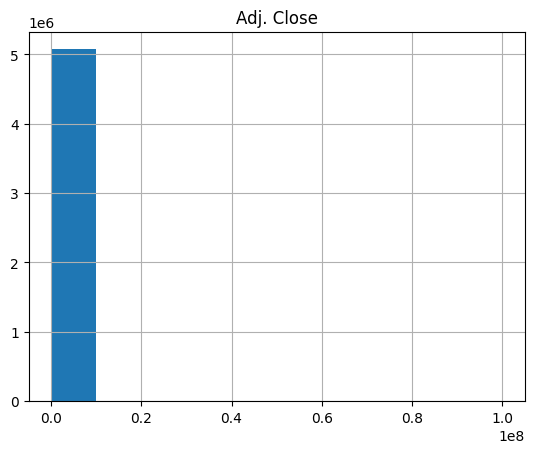

In [6]:
plot = df.hist(column="Adj. Close")

<Axes: >

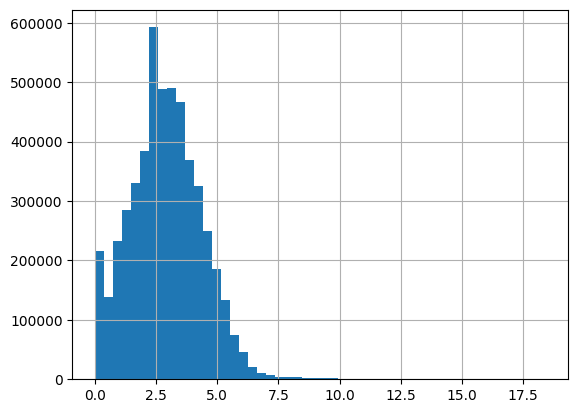

In [7]:
df["log_adj_close"] = np.log1p(df["Adj. Close"])
df["log_adj_close"].hist(bins=50)

Since the current dataset contains so many missing or unreliable values like -100.000 / 100.000. Or is just heavily influenced by the huge differences between prices. Producing any visually usable graph without logging is impossible. So we log the data to make the target variable visually understandable.

We can see the data is lightly skewed but mostly normally distributed.

# Preprocessing

Since the dataset is full of outliers, huge differences in values, and missing values or unusable values, as well as text values. This imposes challenging but interesting work for making the dataset suitable for a machine learning model. Since this is still the baseline model, we will keep preprocessing for now as minimally as possible to be able to use the dataset.

In [8]:
print(df[["Adj. Close", "log_adj_close"]].corr())

               Adj. Close  log_adj_close
Adj. Close       1.000000       0.173375
log_adj_close    0.173375       1.000000


In [9]:
print(df.shape)

(5077223, 16)


In [10]:
print(df.isnull().sum().sort_values(ascending=False))

Dividend Yield                   3440746
Price to Free Cash Flow (ttm)    2319044
Altman Z Score                   2218098
EV/Sales                         1876313
EV/EBITDA                        1864929
Price to Sales Ratio (ttm)       1803041
Operating Income/EV              1499442
Price to Earnings Ratio (ttm)    1457355
Book to Market Value             1105182
Price to Book Value              1028535
Market-Cap                        230378
Ticker                               873
Adj. Close                             0
Date                                   0
Volume                                 0
log_adj_close                          0
dtype: int64


In [11]:
sentinels = [99999.99999, -99999.99999]

df = df.replace(sentinels, np.nan)

In [12]:
print(df.isnull().sum().sort_values(ascending=False))

Dividend Yield                   3440746
Price to Free Cash Flow (ttm)    2319940
Altman Z Score                   2219239
EV/Sales                         1878725
EV/EBITDA                        1865272
Price to Sales Ratio (ttm)       1806152
Operating Income/EV              1499574
Price to Earnings Ratio (ttm)    1459225
Book to Market Value             1105402
Price to Book Value              1029483
Market-Cap                        230378
Ticker                               873
Adj. Close                             0
Date                                   0
Volume                                 0
log_adj_close                          0
dtype: int64


In [13]:

df = df.dropna()
print(df.columns.tolist())
df = df.drop(columns=["Date", "Ticker"])

X = df.drop(columns=["Adj. Close"])
y = df["Adj. Close"]


['Ticker', 'Date', 'Adj. Close', 'Volume', 'Market-Cap', 'Price to Earnings Ratio (ttm)', 'Price to Sales Ratio (ttm)', 'Price to Book Value', 'Price to Free Cash Flow (ttm)', 'EV/EBITDA', 'EV/Sales', 'Book to Market Value', 'Operating Income/EV', 'Altman Z Score', 'Dividend Yield', 'log_adj_close']


In [14]:
print(df.shape)

(986134, 14)


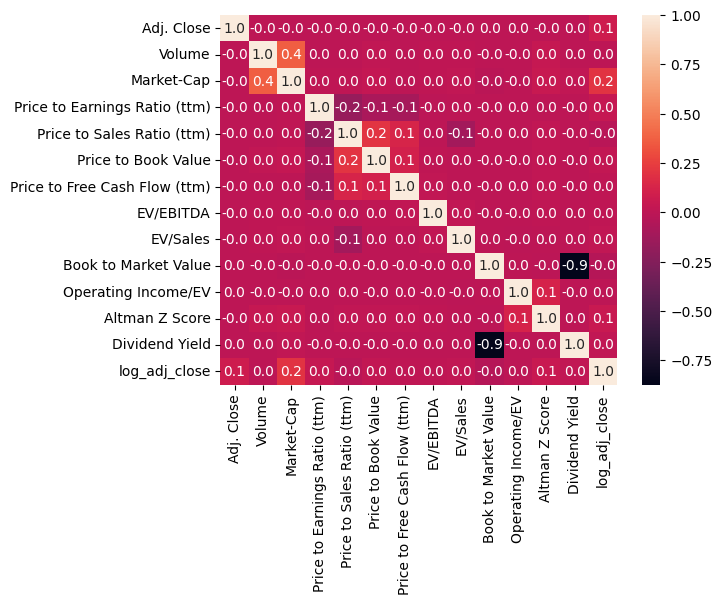

In [15]:
correlations = df.corr()
plot = seaborn.heatmap(correlations, cbar=True, annot=True, fmt=".1f")

In [16]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

Adj. Close                       0.0
Volume                           0.0
Market-Cap                       0.0
Price to Earnings Ratio (ttm)    0.0
Price to Sales Ratio (ttm)       0.0
Price to Book Value              0.0
Price to Free Cash Flow (ttm)    0.0
EV/EBITDA                        0.0
EV/Sales                         0.0
Book to Market Value             0.0
Operating Income/EV              0.0
Altman Z Score                   0.0
Dividend Yield                   0.0
log_adj_close                    0.0
dtype: float64

In [17]:
df.corr(numeric_only=True)["Adj. Close"].sort_values()

Altman Z Score                  -0.001867
Volume                          -0.001281
Market-Cap                      -0.001164
Price to Sales Ratio (ttm)      -0.000503
Price to Book Value             -0.000464
EV/EBITDA                       -0.000445
Price to Earnings Ratio (ttm)   -0.000265
EV/Sales                        -0.000243
Price to Free Cash Flow (ttm)   -0.000059
Dividend Yield                   0.000018
Operating Income/EV              0.000434
Book to Market Value             0.002086
log_adj_close                    0.075868
Adj. Close                       1.000000
Name: Adj. Close, dtype: float64

In [18]:
#Check if all columns are the right datatypes
print(df.dtypes)

Adj. Close                       float64
Volume                             int64
Market-Cap                       float64
Price to Earnings Ratio (ttm)    float64
Price to Sales Ratio (ttm)       float64
Price to Book Value              float64
Price to Free Cash Flow (ttm)    float64
EV/EBITDA                        float64
EV/Sales                         float64
Book to Market Value             float64
Operating Income/EV              float64
Altman Z Score                   float64
Dividend Yield                   float64
log_adj_close                    float64
dtype: object


In [19]:
print(df[["Adj. Close", "log_adj_close"]].corr())

               Adj. Close  log_adj_close
Adj. Close       1.000000       0.075868
log_adj_close    0.075868       1.000000


In [20]:
for col in df.select_dtypes(include=["number"]).columns:
    print(f"\n=== {col} ===")
    print(df[col].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99, 0.999]))

    print("\nTop 10 values:")
    print(df[col].sort_values(ascending=False).head(10))

    print("\nBottom 10 values:")
    print(df[col].sort_values().head(10))


=== Adj. Close ===
count    9.861340e+05
mean     7.023429e+02
std      8.099731e+04
min      1.000000e-02
1%       1.380000e+00
5%       4.210000e+00
50%      4.569000e+01
95%      2.937400e+02
99%      5.911200e+02
99.9%    1.170497e+03
max      1.932336e+07
Name: Adj. Close, dtype: float64

Top 10 values:
4897456    19323360.0
4897436    18144000.0
4897435    18098640.0
4897437    17841600.0
4897438    14515200.0
4897457    14394240.0
4897441    14209776.0
4897455    13728960.0
4897440    13608000.0
4897454    12833856.0
Name: Adj. Close, dtype: float64

Bottom 10 values:
4247705    0.01
4247731    0.01
4247730    0.01
4247729    0.01
4247734    0.01
4247735    0.01
4247736    0.01
4247737    0.01
4247710    0.01
4247749    0.01
Name: Adj. Close, dtype: float64

=== Volume ===
count    9.861340e+05
mean     2.524556e+06
std      1.523763e+07
min      0.000000e+00
1%       2.200000e+02
5%       1.452065e+04
50%      6.405020e+05
95%      8.467351e+06
99%      2.514950e+07
99.9%    1

Shows that the entire dataset each feature contains extreme outlier and placeholder values for NaN values making the dataset unusable in it's current state.

In [21]:
for col in df.columns:
    print(f"\n{'='*50}")
    print(col)
    print('='*50)

    print(df[col].value_counts().head(20))


Adj. Close
Adj. Close
14.55    580
19.75    321
1.00     294
5.00     282
34.00    262
4.00     241
32.00    241
5.55     226
0.01     226
4.50     221
3.80     220
4.69     217
3.90     217
9.50     216
4.01     212
9.20     211
10.00    208
10.30    207
3.75     206
4.35     205
Name: count, dtype: int64

Volume
Volume
0       5708
100      395
1        213
200      196
300      129
2        125
10       102
500       98
50        80
1000      79
400       77
3         75
20        72
5         64
4         54
6         51
600       48
15        48
40        47
150       42
Name: count, dtype: int64

Market-Cap
Market-Cap
8.061000e+09    443
4.516210e+06    174
1.713104e+08    151
1.652941e+08    150
4.065269e+07    129
3.593345e+08    121
3.796333e+07    115
5.764916e+08     87
4.745416e+07     75
7.910528e+07     67
3.585928e+08     66
4.065469e+07     63
1.125415e+08     60
6.795030e+05     60
2.254502e+10     59
3.567782e+08     57
9.675397e+08     52
3.351810e+07     52
3.38221

# Workaround

You can also try and work the other way around instead of arbitraly cleaning up ur dataset. You can just look in the dataset for companies that contain all financial ratios and data. and then just use those companies for the modeling.